# Trial for PySAGES with ASE as a backend.

In [1]:
# ------------------------------- #
# Imports
    # System
import os
import sys
import json
import shutil as sh
import glob
import re

    # System +
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

    # Constraints
from ase.constraints import FixAtoms

    # File io
from ase.io import read, write

    # Other
from ase.visualize.plot import plot_atoms
from ase.data.colors import jmol_colors
from ase.symbols import symbols2numbers
from ase.build.bulk import bulk

# Pymatgen Stuff
from pymatgen.io.vasp import Kpoints

# Mine
from DFTUtils import write_vasp_settings, write_settings_json, get_strain, render_chg_slice
from DFTUtils import copy_files_from_DFTUtilities, remove_files, make_directories_from_list

notebook_path = os.path.dirname(__vsc_ipynb_file__)
plt.rcParams['figure.dpi'] = 150

# Energy-Volume curves of a lennard jones solid in BCC and FCC packing

In [2]:
from ase.calculators.lj import LennardJones
from ase.optimize import BFGS, CellAwareBFGS
from ase.filters import FrechetCellFilter

# ---------------------------------------------------- #
# Simple Cubic
bcc = bulk('Fe', 'bcc', 3.71)
bcc.calc = LennardJones(sigma = 3.0)
bcc_opt = FrechetCellFilter(bcc, mask = [1,1,1,1,1,1])
opt = BFGS(bcc_opt)

opt.run(fmax = 0.001)

print(bcc.cell.cellpar())

# ---------------------------------------------------- #
# Face-Centered Cubic
fcc = bulk('Fe', 'fcc', 3)
fcc.calc = LennardJones(sigma = 3.0)
fcc_opt = FrechetCellFilter(fcc, mask = [1,1,1,1,1,1])
opt = BFGS(fcc_opt)

opt.run(fmax = 0.001)

print(fcc.cell.cellpar())

      Step     Time          Energy          fmax
BFGS:    0 15:59:56       -7.580753        0.233955
BFGS:    1 15:59:56       -7.579920        0.393746
BFGS:    2 15:59:56       -7.581180        0.004431
BFGS:    3 15:59:56       -7.581180        0.000085
[  3.21688235   3.21688235   3.21688235 109.47122063 109.47122063
 109.47122063]
      Step     Time          Energy          fmax
BFGS:    0 15:59:56     1324.099267     5751.449178
BFGS:    1 15:59:56       72.580350      425.549483
BFGS:    2 15:59:56       54.299147      339.953798
BFGS:    3 15:59:56       12.120357      131.740230
BFGS:    4 15:59:56        0.496513       67.098823
BFGS:    5 15:59:56       -5.293583       29.317182
BFGS:    6 15:59:56       -7.246578       12.327816
BFGS:    7 15:59:56       -7.819344        4.443414
BFGS:    8 15:59:56       -7.928264        1.170360
BFGS:    9 15:59:56       -7.937685        0.171534
BFGS:   10 15:59:56       -7.937903        0.008324
BFGS:   11 15:59:56       -7.937904    

In [3]:
columns = ['Energy',
           'Volume',
           ]
bcc_data = pd.DataFrame(columns = columns)
fcc_data = pd.DataFrame(columns = columns)

bcc_original = bcc.copy()
fcc_original = fcc.copy()

scaled_volumes = np.linspace(0.8, 1.4, 15)
for ind, scaled_volume in enumerate(scaled_volumes):
    bcc.set_cell(bcc_original.cell[:] * scaled_volume ** (1/3), scale_atoms=True)
    fcc.set_cell(fcc_original.cell[:] * scaled_volume ** (1/3), scale_atoms=True)

    bcc_data.at[ind, 'Energy'] = bcc.get_potential_energy()
    bcc_data.at[ind, 'Volume'] = bcc.get_volume()

    fcc_data.at[ind, 'Energy'] = fcc.get_potential_energy()
    fcc_data.at[ind, 'Volume'] = fcc.get_volume()

<Axes: >

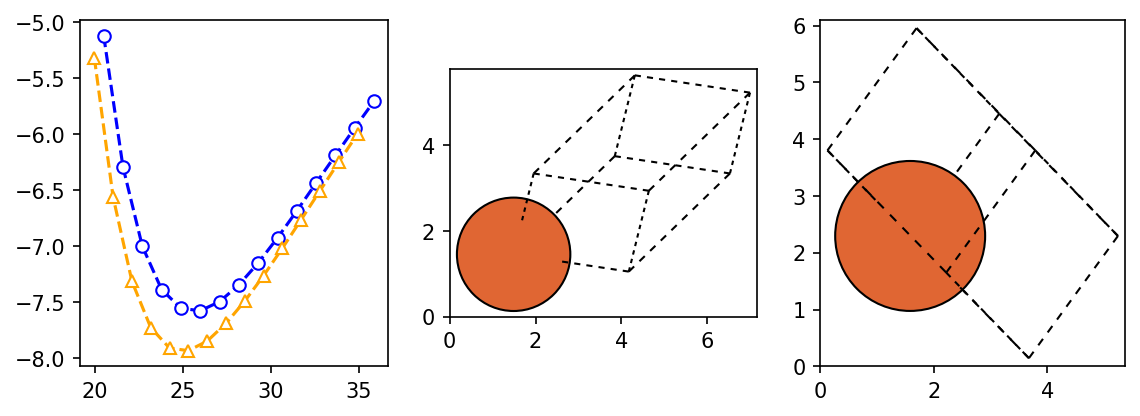

In [4]:
plot_settings = {'mfc': 'white', 'linestyle': 'dashed'}
rotation = '10x,10y,0z'

fig, axes = plt.subplots(1,3, figsize = (9,3))
axes[0].plot(bcc_data['Volume'], bcc_data['Energy'], marker = 'o', color = 'blue', **plot_settings)
axes[0].plot(fcc_data['Volume'], fcc_data['Energy'], marker = '^', color = 'orange', **plot_settings)

plot_atoms(fcc_original, axes[1], rotation = rotation)
plot_atoms(bcc_original, axes[2], rotation = rotation)

# SSNEB Initial Guess?

ValueError: operands could not be broadcast together with shapes (16,3) (32,3) 

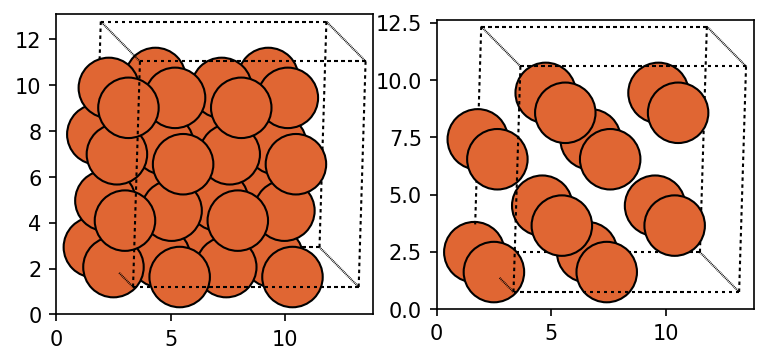

In [41]:
from ase.mep import NEB
from ase.optimize import FIRE2
from tsase.neb import ssneb, fire_ssneb

# ----------------------------- #
# Set Structures
fcc = bulk('Fe', 'fcc', 5.0, cubic = True)
initial = fcc.repeat(2)

bcc = bulk('Fe', 'bcc', 5.0, cubic = True)
final = bcc.repeat(2)
# final.set_cell(initial.cell[:], scale_atoms = True)

fig, axes = plt.subplots(1,2, figsize = (6,3))
plot_atoms(initial, axes[0], rotation = '10x,10y,0z')
plot_atoms(final, axes[1], rotation = '10x,10y,0z')

# ----------------------------- #
# Set NEB
neb_settings = {'restart':False,
                'n_images':5,
                'fmax': 0.003,
                'method': 'improvedtangent',
                'k': 1,
                'climb': False,
                'optimizer': 'BFGS'
                }

restart = neb_settings.pop('restart')
n_images = neb_settings.pop('n_images')
fmax = neb_settings.pop('fmax')
optimizer = neb_settings.pop('optimizer')

ssneb_settings = {
    # Optimizer filter
    'k': 1,
    'tangent': 'new',
    'method': 'ci', # designates climbing image (ci) or no
    'express': (0 * np.array([[1,0,0],
                        [0,1,0],
                        [0,0,1]])).tolist(), # tensor in GPa, converted to eV/A^3
}
express = np.array(ssneb_settings.pop('express'))
# ----------------------------- #
# 
images = [initial]
images += [initial.copy() for i in range(n_images-2)]
images += [final]

# ----------------------------- #
# Attach optimizer
for image in images:
    image.calc = LennardJones()

neb = ssneb(initial, final, **ssneb_settings)

opt = fire_ssneb(neb)

opt.minimize(forceConverged=fmax)

# Steinhardt

In [24]:
def calculate_steinhardt(L, atoms, steinhardt_kwargs = {}):
    """
    Calculates Steinhardt order parameter using the Glotzer group's Freud interface.
    Args:
    L (int): Spherical harmonic order
    atoms (ASE Atoms): atoms object to pass
    steinhardt_kwargs (dict): kwargs for freud Steinhardt {average:False, wl:False, weighted:False, wl_normalize:False}
    """
    # -------------------------------------- #
    # Sub-Function
    def atoms_to_system(atoms):
        """
        Converts ASE atoms to a Freud "system".
        
        Args:
        atoms (ASE Atoms): atoms object to convert.
        """
        from freud.box import Box

        box = Box.from_matrix(atoms.cell[:])
        points = atoms.get_positions()
        return (box, points)
    
    # -------------------------------------- #
    # Calculate Steinhardt order parameter
    from freud.order import Steinhardt

    # --------------- #
    print(f'{len(atoms)} atoms in cell')
    system = atoms_to_system(atoms)
    # --------------- #

    q_l = Steinhardt(L, **steinhardt_kwargs)
    particle_order = q_l.compute(system, neighbors={"num_neighbors": L}).particle_order
    
    return particle_order

250 atoms in cell
250 atoms in cell
250 atoms in cell
250 atoms in cell
250 atoms in cell
250 atoms in cell
125 atoms in cell
125 atoms in cell
125 atoms in cell


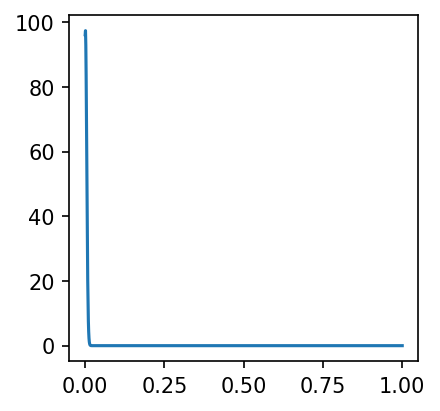

In [25]:
steinhardt_kwargs = {'average': True, 'wl': True,'weighted': False, 'wl_normalize': False}
sig = 0.35
# ------------------------------------------------------ #
# Build structure
fcc = bulk('Fe', 'fcc', 5.0, orthorhombic = True)
fcc_repeated = fcc.repeat(5)
fcc_repeated.rattle(sig)

bcc = bulk('Fe', 'bcc', 5.0, orthorhombic = True)
bcc_repeated = bcc.repeat(5)
bcc_repeated.rattle(sig)

sc = bulk('Fe', 'sc', 5.0, orthorhombic = True)
sc_repeated = sc.repeat(5)
sc_repeated.rattle(sig)

# ------------------------------------------------------ #
# Calculate order for all 
particle_order = calculate_steinhardt(12, fcc_repeated, steinhardt_kwargs)
particle_order_2 = calculate_steinhardt(8, fcc_repeated, steinhardt_kwargs)
particle_order_3 = calculate_steinhardt(6, fcc_repeated, steinhardt_kwargs)

b_particle_order = calculate_steinhardt(12, bcc_repeated, steinhardt_kwargs)
b_particle_order_2 = calculate_steinhardt(8, bcc_repeated, steinhardt_kwargs)
b_particle_order_3 = calculate_steinhardt(6, bcc_repeated, steinhardt_kwargs)

s_particle_order = calculate_steinhardt(12, sc_repeated, steinhardt_kwargs)
s_particle_order_2 = calculate_steinhardt(8, sc_repeated, steinhardt_kwargs)
s_particle_order_3 = calculate_steinhardt(6, sc_repeated, steinhardt_kwargs)

# ------------------------------------------------------ #
# Convert histogram into something that looks cooler
from sklearn.neighbors import KernelDensity

bins = np.linspace(0,1,1000)

kde = KernelDensity(bandwidth=0.004)
kde.fit(particle_order[:, np.newaxis])
ql = np.exp(kde.score_samples(bins[:, np.newaxis]))

fig, ax = plt.subplots(figsize = (3,3))
ax.plot(bins, ql)

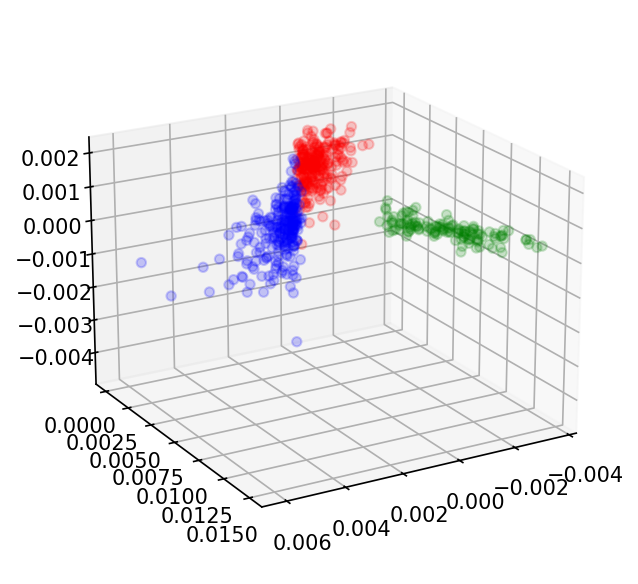

In [26]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

ax.scatter(particle_order, particle_order_2, particle_order_3, c = 'blue', alpha = 0.2)
ax.scatter(b_particle_order, b_particle_order_2, b_particle_order_3, c = 'red', alpha = 0.2)
ax.scatter(s_particle_order, s_particle_order_2, s_particle_order_3, c = 'green', alpha = 0.2)

# ax.set_xlim((0,1))
# ax.set_ylim((0,1))
# ax.set_zlim((0,1))

ax.view_init(elev=20, azim=60) 